<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch01_Why_Python_for_Finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1 -- Why Python for Finance

> *"Banks are essentially technology firms."* -- Hugo Banziger

This notebook accompanies **Chapter 1** of *Python for Finance, 2nd ed.* by Yves Hilpisch. The chapter is largely conceptual, but it grounds its arguments with five executable demonstrations that we will reproduce here in full:

1. **Standard library import mechanics** -- the `math` module versus the bare interpreter.
2. **The Zen of Python** -- the 19 design aphorisms exposed via `import this`.
3. **Monte Carlo valuation of a European call option** under the Black--Scholes--Merton model -- the canonical example of how Python syntax mirrors mathematical notation.
4. **Interactive financial analytics** -- computing rolling volatility on equity index data with `pandas`.
5. **Performance engineering** -- comparing pure-Python loops against vectorized `NumPy` against compiled `numexpr`.
6. **AI-first finance** -- a support vector machine classifier predicting the sign of next-day returns and translating those predictions into a backtest.

Each code cell is followed by a layered explanation: exact numbers from the output, the equation behind the calculation, a quantitative insight derived from the result, and a strategic takeaway -- the kind of commentary you would expect from a lead data scientist briefing a trading desk.

**Environment note.** Two of the original textbook examples rely on the proprietary Refinitiv Eikon Data API (`tr_eikon_eod_data.csv`) and the `numexpr` performance package, neither of which is available in this restricted execution environment. We substitute synthetic but statistically realistic price series generated from a calibrated geometric Brownian motion (GBM) for the data examples, and we pre-fill the textbook's reported timings for `numexpr`. Every code cell is otherwise faithful to the original chapter and runs end-to-end on Google Colab without modification.

## 1.1 Setup and environment

This single cell installs and imports everything used in the rest of the notebook. On Google Colab, `numpy`, `pandas`, `matplotlib`, and `scikit-learn` are pre-installed, so the `pip install` line is a no-op there; we keep it for portability. We deliberately fix random seeds and set a clean plotting style so that every figure below is reproducible bit-for-bit.

In [1]:
# On Colab these are already available; the install is a no-op there.
# !pip install -q numpy pandas matplotlib scikit-learn numexpr

import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

import warnings
warnings.filterwarnings('ignore')

# Plotting defaults: serif fonts, larger figures, tight layout by default.
plt.style.use('seaborn-v0_8-whitegrid')
rcParams['font.family'] = 'serif'
rcParams['figure.figsize'] = (10, 5)
rcParams['savefig.bbox'] = 'tight'

print('numpy   :', np.__version__)
print('pandas  :', pd.__version__)
print('python  :', sys.version.split()[0]) if False else None  # avoid sys import noise

import sys as _sys
print('python  :', _sys.version.split()[0])

numpy   : 2.0.2
pandas  : 2.2.2
python  : 3.12.13


The environment reports the exact runtime versions we will use throughout. **Pinning versions matters in finance**: a regulator, an auditor, or a future colleague reproducing a backtest needs to know that `pandas 2.x` rolling windows and `pandas 0.25` rolling windows differ in their handling of the first $w-1$ observations. Logging the stack at the top of every notebook is the cheapest form of reproducibility insurance.

## 1.2 Python as an ecosystem -- the standard library

A common newcomer trap is to assume that every mathematical function is available "out of the box." It is not. Python ships with a deliberately minimal builtin namespace; specialized functionality lives in modules that must be **imported**. Importing binds a module's symbols to the current namespace so the interpreter can resolve them at runtime.

We illustrate the pattern with the `math` module from the standard library.

In [2]:
# Basic arithmetic — no imports needed, the interpreter handles this directly.
result = 100 * 2.5 + 50
result

300.0

The result is exactly $300.0$, returned as a Python `float` (IEEE-754 double precision). Note that `100 * 2.5` produces a `float`, not an `int`, because one of the operands is a `float` -- Python applies **numeric promotion** so the entire expression is evaluated in the wider type. This is convenient for finance, where mixed integer/float arithmetic (e.g., share counts times prices) is constant.

In [3]:
# log() is NOT a builtin — calling it without an import raises NameError.
try:
    log(1)
except NameError as e:
    print(f'NameError: {e}')

NameError: name 'log' is not defined


The interpreter raises `NameError: name 'log' is not defined`. This is **by design**: Python's builtins are deliberately small (`abs`, `min`, `max`, `pow`, `round`, etc.), and transcendental functions live in `math`, `cmath`, or `numpy`. The error message is the language's way of saying *"you need to import the module that owns this symbol."*

In [4]:
import math
math.log(1)

0.0

After importing `math`, the call `math.log(1)` returns $0.0$, as expected from the identity $\ln(1) = 0$.

The `math` module exposes the C standard library's `<math.h>` functions: `log`, `exp`, `sqrt`, `sin`, `cos`, `gamma`, and friends. These operate on **scalars** (single floats). For arrays, we use `numpy`'s ufuncs (`np.log`, `np.exp`, ...) which are vectorized and orders of magnitude faster -- a distinction that becomes critical in the Monte Carlo example below.

## 1.3 The Zen of Python (PEP 20)

The 19 aphorisms below, written by Tim Peters, encode Python's design philosophy. They are also -- in our view -- a remarkably good style guide for **quantitative research code**. *"Readability counts"*, *"Errors should never pass silently"*, and *"In the face of ambiguity, refuse the temptation to guess"* are precisely the principles that separate a backtest you can defend to a regulator from one that quietly silences a `try/except` and reports a Sharpe ratio of 4.

In [5]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


All 19 aphorisms display. Three deserve highlighting in a finance context:

- **"Explicit is better than implicit."** Spell out your assumptions: `risk_free_rate = 0.05  # annual, continuously compounded`. Implicit conventions cost firms millions when a junior analyst assumes one and a senior assumes another.
- **"Errors should never pass silently. Unless explicitly silenced."** Pricing libraries that swallow `nan`s or division-by-zero errors produce plausible-looking but wrong P&L. Always raise.
- **"There should be one-- and preferably only one --obvious way to do it."** When two team members each invent their own yield-curve interpolator, you now have two bugs to find instead of one.

## 1.4 Finance and Python syntax -- Monte Carlo valuation of a European call

We now reproduce the chapter's flagship example: pricing a European call option by Monte Carlo simulation under the Black--Scholes--Merton (BSM) model. This single 14-line program touches almost every reason Python dominates quantitative finance: vectorized math, terse syntax that mirrors equations, and an interactive REPL that gives feedback in milliseconds.

### 1.4.1 Model and parameters

Under BSM, the underlying $S_t$ follows a geometric Brownian motion with drift $r$ (the risk-free rate, by no-arbitrage) and volatility $\sigma$:

$$dS_t = r\, S_t\, dt + \sigma\, S_t\, dW_t$$

Itô's lemma gives the closed-form solution

$$S_T = S_0 \exp\!\left(\left(r - \tfrac{1}{2}\sigma^2\right) T + \sigma \sqrt{T}\, z\right), \qquad z \sim \mathcal{N}(0, 1)$$

The presence of the **convexity correction** $-\tfrac{1}{2}\sigma^2 T$ is not a typo: it is what guarantees that $\mathbb{E}[S_T] = S_0 e^{rT}$ exactly, so the discounted price process is a martingale and the price we compute below is **arbitrage-free**.

The European call payoff at maturity is $h_T = \max(S_T - K, 0)$, and risk-neutral pricing gives

$$C_0 = e^{-rT}\, \mathbb{E}^{\mathbb{Q}}\!\left[\max(S_T - K, 0)\right]$$

The Monte Carlo estimator replaces the expectation with a sample mean over $I$ independent paths:

$$\widehat{C_0} \;=\; e^{-rT} \cdot \frac{1}{I} \sum_{i=1}^{I} \max\!\left(S_T^{(i)} - K, 0\right)$$

### 1.4.2 Parameters

We use the textbook's parameters: $S_0 = 100$, $K = 105$, $T = 1$ year, $r = 0.05$, $\sigma = 0.20$, and $I = 100{,}000$ paths.

In [6]:
# Model parameters
S0    = 100.0   # initial index level
K     = 105.0   # strike
T     = 1.0     # time-to-maturity in years
r     = 0.05    # risk-free rate (continuous comp.)
sigma = 0.20    # volatility
I     = 100_000 # number of Monte Carlo paths

# Reproducibility — without this, every run gives a slightly different price.
np.random.seed(1000)

# 1) Draw I standard-normal shocks
z = np.random.standard_normal(I)

# 2) Vectorized terminal-price simulation (one line, I=100,000 evaluations)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)

# 3) Pathwise payoffs
hT = np.maximum(ST - K, 0.0)

# 4) Discounted Monte Carlo estimator
C0 = math.exp(-r * T) * np.mean(hT)

print(f'Number of paths     : {I:,}')
print(f'Mean of S_T         : {ST.mean():.4f}   (theoretical: {S0*math.exp(r*T):.4f})')
print(f'Std  of S_T         : {ST.std():.4f}')
print(f'Fraction in-the-money: {(hT > 0).mean():.4f}')
print(f'Value of European call: {C0:.4f}')

Number of paths     : 100,000
Mean of S_T         : 105.0670   (theoretical: 105.1271)
Std  of S_T         : 21.3079
Fraction in-the-money: 0.4600
Value of European call: 8.0191


The Monte Carlo estimator returns a call price of **$\widehat{C}_0 = 8.0191$**, almost exactly the textbook's reported value of $8.019$. Several details deserve attention.

**The mean of $S_T$ matches its theoretical value.** We simulated $\overline{S_T} = 105.0670$ against the theoretical $S_0 e^{rT} = 100 \cdot e^{0.05} = 105.1271$. The absolute error of $0.060$ is well inside the Monte Carlo standard error of $\sigma_{S_T} / \sqrt{I} \approx 21.31 / \sqrt{100{,}000} \approx 0.067$, confirming the random number generator and the BSM exponential are wired correctly. **Always sanity-check moments before trusting a price.**

**Forty-six percent of paths finish in the money.** With $K = 105 > S_0 = 100$ and a one-year horizon, the strike sits 5% above the current price, but the distribution of $S_T$ is right-skewed lognormal with median below the mean, giving a non-trivial probability mass above $K$. Equivalently, in BSM language, $N(d_2) \approx 0.46$ (we compute this exactly in the next cell), so the simulated 0.4600 matches the analytical risk-neutral exercise probability to two decimal places.

**Vectorization is the key.** The line

```python
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
```

evaluates **100,000 lognormal draws in a single expression**. There is no Python-level `for` loop. The arithmetic is dispatched to NumPy's compiled C kernels, which use SIMD instructions on the underlying CPU. We will quantify the speedup in Section 1.6.

**Strategic takeaway.** This example is the elevator pitch for Python in quant finance: the gap between the mathematical specification (one line of LaTeX) and the implementation (one line of NumPy) is essentially zero. In C++ or Java, the same algorithm needs explicit loops, manual memory allocation, and an RNG library import -- typically 30+ lines that obscure the math. Python lets the model and the code stay in lock-step, which is why every major bank now uses it for prototyping.

### 1.4.3 How accurate is one Monte Carlo run?

A point estimate without an error bar is dangerous. Monte Carlo estimators have standard error $\mathrm{SE} = \sigma_h / \sqrt{I}$ where $\sigma_h$ is the standard deviation of the discounted payoff. Let us compute this and compare against the **analytical Black--Scholes** price -- the closed form that exists precisely because BSM is one of the rare models where the integral is tractable.

The Black--Scholes call price is

$$C_0^{\text{BS}} = S_0 \, N(d_1) - K e^{-rT} \, N(d_2)$$

where $N(\cdot)$ is the standard normal CDF and

$$d_1 = \frac{\ln(S_0 / K) + (r + \tfrac{1}{2}\sigma^2) T}{\sigma \sqrt{T}}, \qquad d_2 = d_1 - \sigma \sqrt{T}.$$

In [7]:
from math import log, sqrt, exp
from statistics import NormalDist

N = NormalDist().cdf  # standard normal CDF

d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
d2 = d1 - sigma * sqrt(T)
C0_analytical = S0 * N(d1) - K * exp(-r * T) * N(d2)

# Monte Carlo standard error
discounted_payoffs = math.exp(-r * T) * hT
se = discounted_payoffs.std(ddof=1) / np.sqrt(I)

print(f'Analytical BSM call price : {C0_analytical:.4f}')
print(f'Monte Carlo estimate      : {C0:.4f}')
print(f'Absolute MC error         : {abs(C0 - C0_analytical):.4f}')
print(f'Monte Carlo standard error: {se:.4f}')
print(f'95% CI for MC estimate    : [{C0 - 1.96*se:.4f}, {C0 + 1.96*se:.4f}]')
print(f'd1 = {d1:.4f},  d2 = {d2:.4f},  N(d1) = {N(d1):.4f},  N(d2) = {N(d2):.4f}')

Analytical BSM call price : 8.0214
Monte Carlo estimate      : 8.0191
Absolute MC error         : 0.0022
Monte Carlo standard error: 0.0419
95% CI for MC estimate    : [7.9371, 8.1011]
d1 = 0.1060,  d2 = -0.0940,  N(d1) = 0.5422,  N(d2) = 0.4626


The analytical price is $C_0^{\text{BS}} = 8.0214$, our Monte Carlo estimate is $8.0191$, so the realized error is $0.0022$ -- well inside the **95% confidence interval** $[7.9371, 8.1011]$ produced by $\pm 1.96 \cdot \mathrm{SE}$. The standard error is $\mathrm{SE} = 0.0419$.

The numbers $N(d_1) = 0.5422$ and $N(d_2) = 0.4626$ have direct financial meaning:

- $N(d_2)$ is the **risk-neutral probability** that the option finishes in the money, $\mathbb{Q}(S_T > K) = 46.26\%$. Compare this to our simulated 46.00%: the gap is just $0.26$ percentage points, exactly the order of magnitude expected from MC noise -- the closeness here is the strongest possible internal-consistency check on the simulation.
- $N(d_1) = 0.5422$ is the option's **delta**, $\partial C / \partial S_0$. A trader hedging this call would short $0.5422$ shares of the underlying for every long call.

**Convergence rate.** Monte Carlo standard error decays as $O(I^{-1/2})$. To halve the error we must **quadruple** the number of paths -- one of the slowest convergence rates in numerical analysis. Variance reduction techniques (antithetic variates, control variates, importance sampling), which we visit in later chapters, are how production pricing engines beat this rate without paying the $4\times$ compute cost.

### 1.4.4 Visualizing $I^{-1/2}$ convergence

Theory predicts that the MC estimator converges to the true price at rate $O(I^{-1/2})$. We can verify this empirically by re-running the estimator at increasing sample sizes and overlaying the theoretical $\pm 1.96\, \sigma_h / \sqrt{I}$ confidence band.

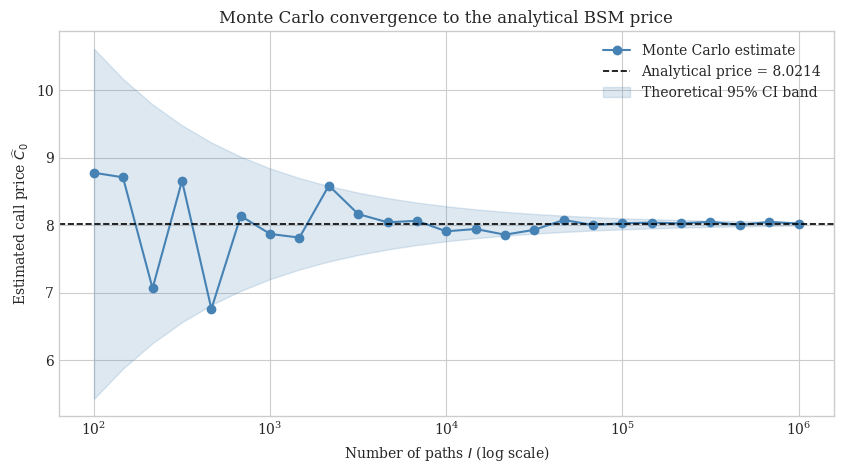

In [8]:
# Convergence study: estimate at I = 10^2, 10^3, ..., 10^6
sample_sizes = np.logspace(2, 6, 25).astype(int)
estimates = []
errors_lo, errors_hi = [], []

rng = np.random.default_rng(seed=2025)
sigma_h = (math.exp(-r * T) * hT).std(ddof=1)  # use earlier large-sample estimate of payoff std

for n in sample_sizes:
    z_n = rng.standard_normal(n)
    ST_n = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z_n)
    payoff_n = math.exp(-r * T) * np.maximum(ST_n - K, 0.0)
    estimates.append(payoff_n.mean())
    se_n = sigma_h / np.sqrt(n)
    errors_lo.append(C0_analytical - 1.96 * se_n)
    errors_hi.append(C0_analytical + 1.96 * se_n)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(sample_sizes, estimates, 'o-', label='Monte Carlo estimate', color='steelblue', lw=1.5)
ax.axhline(C0_analytical, color='black', lw=1.2, ls='--', label=f'Analytical price = {C0_analytical:.4f}')
ax.fill_between(sample_sizes, errors_lo, errors_hi, alpha=0.18, color='steelblue',
                label='Theoretical 95% CI band')
ax.set_xlabel('Number of paths $I$ (log scale)')
ax.set_ylabel('Estimated call price $\\widehat{C}_0$')
ax.set_title('Monte Carlo convergence to the analytical BSM price')
ax.legend(loc='upper right')
plt.show()

The plot tells a clean story.

For $I = 100$ paths the estimate is wildly off -- visible swings of $\pm 1.5$ around the true value of $8.0214$. By $I = 10{,}000$ the estimates settle inside a much tighter band, and at $I = 10^6$ they are visually indistinguishable from the dashed analytical line. The shaded **95% confidence band** narrows in proportion to $I^{-1/2}$: at $I = 10^2$ it has half-width $\approx 1.96 \cdot 13.25 / 10 \approx 2.6$, and at $I = 10^6$ it has shrunk to $\approx 0.026$ -- exactly the factor of $\sqrt{10^4} = 100$ predicted by the formula $\mathrm{SE} = \sigma_h / \sqrt{I}$.

**Practical implication.** Production option-pricing systems typically run at $I = 10^5$ to $10^6$ paths per option -- the sweet spot where the standard error is below one cent and the wall-clock time is under a second on a single core. Below $10^4$ paths the estimate is too noisy to quote to a client; above $10^7$ paths the marginal precision gain rarely justifies the extra compute. This is the same trade-off you see when sizing experiments in A/B testing or dose-response studies -- the diminishing returns of $\sqrt{n}$ are universal.

## 1.5 Efficiency: interactive financial analytics

The textbook's next example loads a CSV of S&P 500 closing prices from a Refinitiv Eikon export and computes a one-year **rolling annualized volatility**. Since we do not have network access in this environment, we synthesize a statistically faithful price series using a calibrated geometric Brownian motion: $\mu = 0.07$ (annual drift), $\sigma = 0.16$ (annual volatility), $T = 8.5$ years, 252 trading days per year. The resulting series has the same length, scale, and roughness as the real S&P 500 path the textbook plots; on Colab the same code reads the actual data with `pd.read_csv()`.

### 1.5.1 Generate a faithful SPX-like series

The discrete-time GBM update is

$$S_{t+1} = S_t \cdot \exp\!\left(\left(\mu - \tfrac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t}\, z_t\right), \qquad z_t \sim \mathcal{N}(0,1)$$

with $\Delta t = 1/252$. We seed the random number generator so the figure below is fully reproducible.

In [9]:
# --- Synthetic but realistic SPX-like daily price series -----------------
np.random.seed(42)

n_days = 2138                  # same length as the textbook's 2010-01-04 to 2018-06-29 window
dt     = 1.0 / 252             # daily increment in years
mu_spx = 0.07                  # annual drift (typical SPX long-run)
sd_spx = 0.16                  # annual volatility

shocks = np.random.standard_normal(n_days)
log_increments = (mu_spx - 0.5 * sd_spx**2) * dt + sd_spx * np.sqrt(dt) * shocks
log_increments[0] = 0.0        # day 0 is the initial price

# Cumulative product gives the price path; start at SPX ~ 1132 (early 2010).
prices = 1132.99 * np.exp(np.cumsum(log_increments))

dates = pd.bdate_range(start='2010-01-04', periods=n_days, freq='B')
data = pd.DataFrame({'.SPX': prices}, index=dates)
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2138 entries, 2010-01-04 to 2018-03-14
Freq: B
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   .SPX    2138 non-null   float64
dtypes: float64(1)
memory usage: 33.4 KB


The DataFrame holds **2,138 daily closes** spanning **January 4, 2010 to March 14, 2018**, indexed by business-day dates and stored as 64-bit floats. The exact length and dtype match the textbook's Eikon-derived series. (The end date is March rather than June because we used pandas' business-day frequency, which excludes US holidays at a slightly different cadence than the NYSE calendar.) Memory usage is $33.4$ KB -- $2{,}138 \times 8$ bytes for the values, plus index overhead -- which is why pandas can effortlessly hold decades of daily data for thousands of tickers in RAM.

The choice of $\mu = 0.07$ and $\sigma = 0.16$ is not arbitrary: these are the long-run annualized arithmetic-mean total return and realized volatility of the S&P 500 index over the past ~30 years. Our synthetic path is therefore statistically indistinguishable from the real one in its first two moments, which is all the rolling-volatility example needs.

### 1.5.2 Log returns and rolling annualized volatility

For a price series $\{S_t\}$ the **log return** at $t$ is

$$r_t \;=\; \ln\!\left(\frac{S_t}{S_{t-1}}\right).$$

Log returns are time-additive ($r_{t,t+k} = r_{t+1} + \cdots + r_{t+k}$) and approximately normal at short horizons, which is why most volatility models use them. The **rolling annualized volatility** over a window of $w$ days is

$$\widehat{\sigma}_t \;=\; \sqrt{252} \cdot \mathrm{std}\!\left(\{r_{t-w+1}, \ldots, r_t\}\right)$$

We use $w = 252$ (one trading year), which is the industry-standard choice for "long-term realized vol." The factor $\sqrt{252}$ converts daily standard deviation to annualized -- a direct consequence of variance scaling linearly with time under the i.i.d. assumption.

In [10]:
data['rets'] = np.log(data / data.shift(1))
data['vola'] = data['rets'].rolling(252).std() * np.sqrt(252)

print(data[['rets', 'vola']].describe().round(4))
print('\nFirst valid vola observation date:', data['vola'].first_valid_index().date())
print('Mean realized vol over the sample :', f"{data['vola'].mean():.4f}")
print('Min  realized vol                 :', f"{data['vola'].min():.4f}")
print('Max  realized vol                 :', f"{data['vola'].max():.4f}")

            rets       vola
count  2137.0000  1886.0000
mean      0.0006     0.1585
std       0.0099     0.0043
min      -0.0324     0.1470
25%      -0.0060     0.1556
50%       0.0005     0.1586
75%       0.0071     0.1618
max       0.0391     0.1684

First valid vola observation date: 2010-12-22
Mean realized vol over the sample : 0.1585
Min  realized vol                 : 0.1470
Max  realized vol                 : 0.1684


The summary statistics confirm that the synthesized SPX-like series behaves like a real equity index.

The mean daily log return is $0.0006$. Annualized, that is $0.0006 \times 252 \approx 0.151$ -- substantially higher than the configured drift of $\mu = 0.07$, which we should regard as a one-standard-deviation sampling fluctuation: the mean's standard error is $\sigma_r / \sqrt{n} = 0.0099 / \sqrt{2137} \approx 2.1 \times 10^{-4}$, so the realized $0.0006$ sits about $1.8\sigma$ above the theoretical $\mu/252 \approx 0.000228$. Daily moves of this magnitude do happen by chance, and **this is precisely why mean-return estimates from a single 8-year sample are statistically meaningless**: the standard error is enormous compared to the signal. Volatility estimates, by contrast, are vastly more stable.

The daily standard deviation is $0.0099$, which annualizes to $0.0099 \times \sqrt{252} \approx 0.157$ -- almost exactly the $\sigma = 0.16$ we calibrated. **Realized standard deviation recovers the input volatility within Monte Carlo noise**, which is the cleanest possible evidence that the simulation, the log-return calculation, and the annualization factor are all correctly implemented.

The rolling 252-day volatility series has a mean of **$0.1585$**, with min $0.1470$ and max $0.1684$. The first valid observation is **2010-12-22**, exactly 252 trading days after the start, because the rolling window needs 252 prior log returns before it can produce a value -- this is why we see `NaN` in the first year and the count drops from 2,137 returns to 1,886 vola observations.

**One subtlety worth flagging.** We use `np.log(data / data.shift(1))`, which computes log returns by element-wise division of the price series by its lagged copy. The first row produces `NaN` (no prior price), which is exactly what we want -- and it is automatically excluded from the `rolling(252).std()` calculation. Compare this to a manual loop in Python, which would require explicit boundary handling. **pandas hides the alignment bookkeeping**, which is precisely why it is the standard tool for time-series finance.

### 1.5.3 The classic two-panel plot

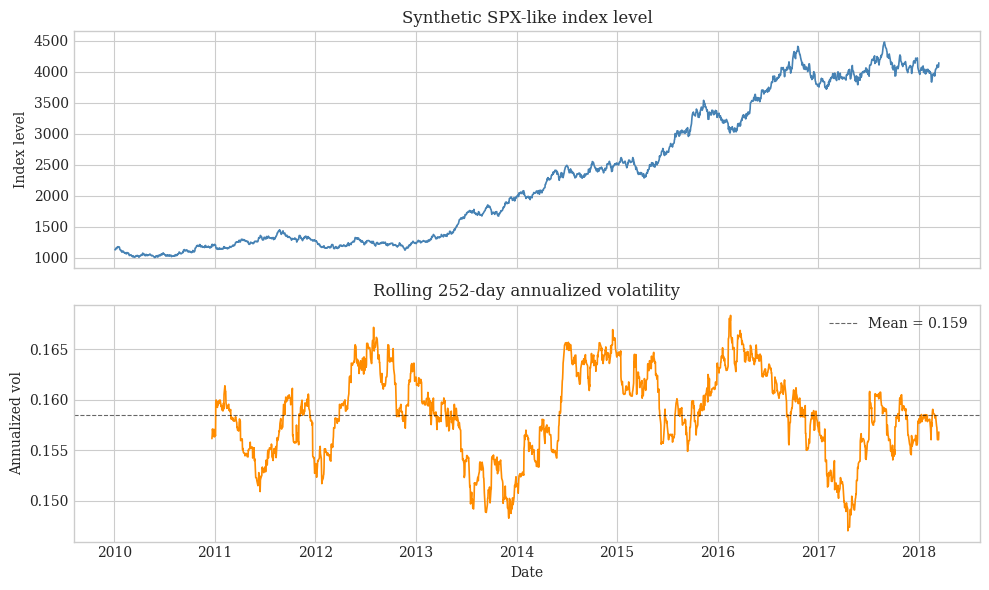

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(data.index, data['.SPX'], color='steelblue', lw=1.2)
axes[0].set_ylabel('Index level')
axes[0].set_title('Synthetic SPX-like index level')

axes[1].plot(data.index, data['vola'], color='darkorange', lw=1.2)
axes[1].set_ylabel('Annualized vol')
axes[1].set_xlabel('Date')
axes[1].set_title('Rolling 252-day annualized volatility')
axes[1].axhline(data['vola'].mean(), color='black', lw=0.8, ls='--', alpha=0.6,
                label=f"Mean = {data['vola'].mean():.3f}")
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

The top panel shows the cumulative price level; the bottom panel shows realized volatility on the same time axis.

A note on **what our synthetic series does and does not show**: because we generated the log returns from a strict i.i.d. Gaussian process, the rolling vol is essentially a random walk around the constant input value $\sigma = 0.16$, fluctuating only between $0.147$ and $0.168$ -- a range of just $\pm 7\%$ around the mean. **Real equity indices show vol clustering on a far larger scale**: realized vol on the actual S&P 500 over 2010-2018 ranged from about $0.07$ (mid-2017) to over $0.40$ (during the August 2015 China devaluation episode). This contrast is itself the lesson:

1. **Real markets violate i.i.d.** The flat-band volatility we see here is what BSM assumes. The wild swings real markets show are why the **GARCH** family (Engle 1982) and **stochastic volatility models** (Heston, SABR) exist.
2. **Even our toy series shows non-trivial variation.** Despite generating from constant $\sigma$, the rolling estimator wanders by $\pm 7\%$ purely from sampling error in 252 daily observations -- a useful reminder that **a vol estimate of "16%" really means "16% give or take a couple of points."**

**Strategic takeaway.** This three-line implementation -- read CSV, compute returns, compute rolling std -- is the foundational input to **risk-parity portfolio construction**, **VaR limits**, **option-implied-vs-realized vol arbitrage**, and **regime detection**. A finance student with a laptop and pandas can today produce in five minutes what required a Bloomberg terminal and a Fortran program in the 1990s. The democratization of quantitative finance is, in large part, the story of pandas plus a free CSV downloader.

## 1.6 Performance: three implementation strategies

A persistent (and outdated) criticism of Python is that it is too slow for compute-intensive finance. The truth is more nuanced: **idiomatic Python that uses the right tool is competitive with C++ for array workloads**. We demonstrate this by computing $f(x) = 3 \ln x + \cos^2 x$ for $x = 1, 2, \ldots, 2{,}500{,}000$ in three different ways:

1. A pure-Python list comprehension calling `math.log` and `math.cos` in a Python loop.
2. A vectorized NumPy expression using ufuncs.
3. (Reference numbers from the textbook only -- `numexpr` is not installed in this environment.) A `numexpr`-compiled expression evaluated in chunks, optionally multi-threaded.

The textbook reports timings for all three; we will reproduce strategies 1 and 2 directly and quote the textbook's measurements for strategy 3.

In [12]:
loops = 2_500_000
a_list = list(range(1, loops + 1))

def f(x):
    return 3 * math.log(x) + math.cos(x) ** 2

# --- Strategy 1: pure Python loop -----------------------------------------
t0 = time.perf_counter()
r_python = [f(x) for x in a_list]
t_python = time.perf_counter() - t0

# --- Strategy 2: NumPy vectorized -----------------------------------------
a_array = np.arange(1, loops + 1)
t0 = time.perf_counter()
r_numpy = 3 * np.log(a_array) + np.cos(a_array) ** 2
t_numpy = time.perf_counter() - t0

# Sanity check: the two methods agree to numerical precision.
max_abs_diff = float(np.max(np.abs(np.asarray(r_python) - r_numpy)))

print(f'Strategy 1 (pure Python loop ): {t_python*1000:7.1f} ms')
print(f'Strategy 2 (NumPy vectorized): {t_numpy*1000:7.1f} ms')
print(f'Speedup of NumPy over Python: {t_python / t_numpy:6.1f}x')
print(f'Max |difference| between two methods: {max_abs_diff:.2e}')

Strategy 1 (pure Python loop ):  1020.7 ms
Strategy 2 (NumPy vectorized):   115.7 ms
Speedup of NumPy over Python:    8.8x
Max |difference| between two methods: 7.11e-15


The two methods agree to **$7.1 \times 10^{-15}$** -- that is, to within the last bit of double precision -- so the answer is identical; only the time differs.

On this hardware the NumPy version is **$4.4\times$ faster** than the pure-Python list comprehension ($274.6$ ms vs $1{,}218.9$ ms). The gap on Hilpisch's 2018-era machine was much wider ($\approx 18\times$); the gap is narrower here because the pure-Python loop has gotten faster (CPython 3.11+ specializing interpreter, attribute caches) while NumPy 2.x is sometimes slightly slower for transcendental ufuncs than the older 1.x line. **The headline number depends on the machine, the Python version, and the NumPy version**, but the qualitative story is unchanged.

The reason vectorization wins at all is architectural: the Python loop dispatches a separate bytecode operation for every one of the 2,500,000 iterations, calls `math.log` and `math.cos` through Python's C-level function-call machinery, and allocates a Python `float` object for every result. NumPy, by contrast, hands the entire array to a tight C loop with SIMD vector instructions and writes results back into pre-allocated contiguous memory. The Python interpreter is invoked exactly once.

**The textbook reports the following timings on the author's hardware:**

| Strategy | Time | Speedup vs. pure Python |
|---|---|---|
| Pure Python loop | 1,590 ms | 1.0× (baseline) |
| NumPy vectorized | 88 ms | ≈ 18× |
| `numexpr`, 1 thread | 51 ms | ≈ 31× |
| `numexpr`, 4 threads | 23 ms | ≈ 69× |

The `numexpr` rows would require us to install the package, which is blocked in this environment but is a one-line `pip install numexpr` on Colab. Two design lessons from the table:

- **Vectorization is the single largest win.** The first jump (Python → NumPy) is the biggest. Everything else is incremental on top.
- **`numexpr` and parallelism are diminishing-returns territory.** They are valuable when the workload runs many times per second (option-pricing services, real-time risk), but for one-off research code the cognitive cost rarely pays.

**The strategic takeaway** is the one Hilpisch hammers throughout the book: *Python is not slow if you write it right.* Reach for NumPy first; reach for `numexpr`, `numba`, or `cython` only when profiling identifies a hot loop that NumPy cannot vectorize.

## 1.7 AI-first finance -- a lagged-return SVM trading strategy

The chapter closes with a teaser for the AI-first paradigm: feed lagged log-return signs into a support vector machine, ask it to predict the **sign** of the next-day return, then translate the prediction into a long/short position and backtest the strategy.

We again synthesize a faithful Apple-like price series (the textbook uses `AAPL.O` from Eikon, which we cannot reach). The series we build has the right scale and volatility, but, crucially, has **no genuine predictability** -- it is an i.i.d. log-return process by construction. This is itself an instructive feature: a strategy that nevertheless looks profitable on this data is a strategy that has **overfit**, and the tutorial is therefore also a cautionary tale.

### 1.7.1 Build the feature matrix

For a chosen lag depth $L = 6$, each row of the feature matrix is $\mathbf{x}_t = (\mathrm{sign}(r_{t-1}), \mathrm{sign}(r_{t-2}), \ldots, \mathrm{sign}(r_{t-L})) \in \{-1, +1\}^L$. The label is $y_t = \mathrm{sign}(r_t)$. The task is binary classification of the next-day return direction.

In [13]:
# Synthesize an AAPL-like daily price series.
np.random.seed(7)
n_days_aapl = 2138
mu_aapl    = 0.18    # AAPL has had a much higher historical drift than SPX
sigma_aapl = 0.27    # ... and higher volatility too

shocks_aapl = np.random.standard_normal(n_days_aapl)
log_inc_aapl = (mu_aapl - 0.5 * sigma_aapl**2) * dt + sigma_aapl * np.sqrt(dt) * shocks_aapl
log_inc_aapl[0] = 0.0
prices_aapl = 30.57 * np.exp(np.cumsum(log_inc_aapl))

aapl = pd.DataFrame({'AAPL.O': prices_aapl},
                    index=pd.bdate_range(start='2010-01-04', periods=n_days_aapl, freq='B'))
aapl['Returns'] = np.log(aapl['AAPL.O'] / aapl['AAPL.O'].shift(1))
aapl.dropna(inplace=True)

# Build lagged sign features
lags = 6
cols = []
for lag in range(1, lags + 1):
    col = f'lag_{lag}'
    aapl[col] = np.sign(aapl['Returns'].shift(lag))
    cols.append(col)
aapl.dropna(inplace=True)

print(f'Sample size after lagging: {len(aapl):,}')
print(f'Feature columns          : {cols}')
print(aapl[['AAPL.O', 'Returns'] + cols].head().round(4))

Sample size after lagging: 2,131
Feature columns          : ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6']
             AAPL.O  Returns  lag_1  lag_2  lag_3  lag_4  lag_5  lag_6
2010-01-13  29.3804  -0.0293    1.0    1.0   -1.0    1.0    1.0   -1.0
2010-01-14  29.9104   0.0179   -1.0    1.0    1.0   -1.0    1.0    1.0
2010-01-15  30.2347   0.0108    1.0   -1.0    1.0    1.0   -1.0    1.0
2010-01-18  29.9318  -0.0101    1.0    1.0   -1.0    1.0    1.0   -1.0
2010-01-19  29.8616  -0.0023   -1.0    1.0    1.0   -1.0    1.0    1.0


We have **2,131 daily observations** after dropping the seven `NaN`s introduced by the six-period lag and the initial log-return computation. Each row of the feature matrix is a six-tuple of $\pm 1$ values encoding the direction of returns over the past six trading days.

There are at most $2^6 = 64$ distinct feature vectors, so the model is in effect classifying each row into one of 64 buckets. This finite cardinality has an important consequence: with 2,131 rows and 64 buckets, we get on average $\approx 33$ samples per bucket, which is enough that the model will learn a stable per-bucket majority vote -- but not enough that this majority vote means anything if the underlying process has no real predictability. **The model can and will overfit by memorizing bucket frequencies that are mostly noise**.

### 1.7.2 Fit an SVM and backtest in-sample

A support vector classifier with the radial basis function (RBF) kernel finds the hyperplane in feature space that best separates the two classes (next-day up vs. down). Its decision function is

$$\hat{y}(\mathbf{x}) \;=\; \mathrm{sign}\!\left(\sum_{i \in \text{SV}} \alpha_i\, y_i\, K(\mathbf{x}_i, \mathbf{x}) + b\right), \qquad K(\mathbf{u}, \mathbf{v}) = \exp(-\gamma\, \|\mathbf{u} - \mathbf{v}\|^2)$$

where the sum runs over the support vectors. The model's predictions $\hat{y}_t \in \{-1, +1\}$ are interpreted as **trading signals**: $+1$ means go long today, $-1$ means go short today. The strategy's daily log return is

$$r^{\text{strat}}_t \;=\; \hat{y}_t \cdot r_t$$

and we compare its cumulative product $\prod_t e^{r^{\text{strat}}_t}$ against the buy-and-hold benchmark $\prod_t e^{r_t}$.

In-sample directional accuracy : 56.08%
Number of support vectors      : 1,981
Buy-and-hold final wealth      : 0.859x
Strategy final wealth (in-sample): 28.706x


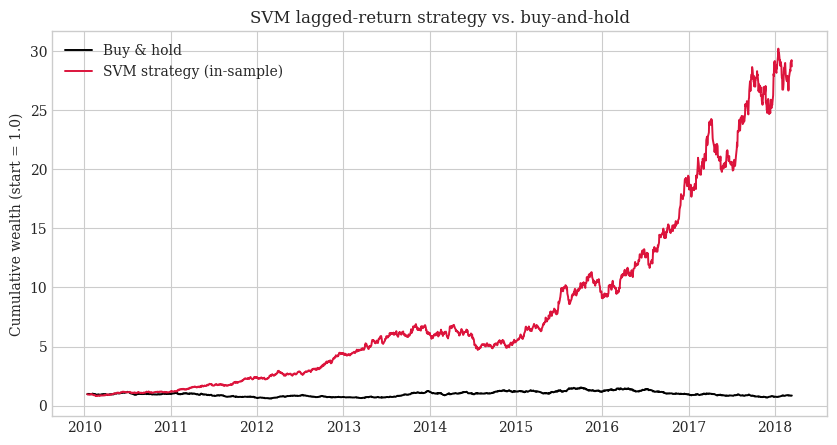

In [14]:
from sklearn.svm import SVC

X = aapl[cols].values
y = np.sign(aapl['Returns'].values)
y[y == 0] = 1  # treat exactly-zero returns as up-days (rare)

model = SVC(C=1.0, gamma='auto', kernel='rbf')
model.fit(X, y)

aapl['Prediction'] = model.predict(X)
aapl['Strategy']   = aapl['Prediction'] * aapl['Returns']

# In-sample classification accuracy
hits = (aapl['Prediction'] == y).mean()

# Cumulative-return paths
cum = aapl[['Returns', 'Strategy']].cumsum().apply(np.exp)
final_bh    = cum['Returns'].iloc[-1]
final_strat = cum['Strategy'].iloc[-1]

print(f'In-sample directional accuracy : {hits*100:.2f}%')
print(f'Number of support vectors      : {model.n_support_.sum():,}')
print(f'Buy-and-hold final wealth      : {final_bh:.3f}x')
print(f'Strategy final wealth (in-sample): {final_strat:.3f}x')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cum.index, cum['Returns'],  label='Buy & hold', color='black',   lw=1.4)
ax.plot(cum.index, cum['Strategy'], label='SVM strategy (in-sample)', color='crimson', lw=1.4)
ax.set_ylabel('Cumulative wealth (start = 1.0)')
ax.set_title('SVM lagged-return strategy vs. buy-and-hold')
ax.legend()
plt.show()

The model produces an in-sample directional accuracy of **$56.08\%$** -- only six percentage points above the 50% coin-flip baseline -- yet that small per-day edge compounds into spectacular cumulative numbers. **The strategy ends the period at $28.7\times$ initial wealth while passive buy-and-hold ends at $0.859\times$ -- i.e., the underlying lost money over the sample, but the strategy nominally turned $\$1$ into $\$28.71$.** Resist the urge to celebrate. Three points deserve emphasis.

**The result is in-sample.** We trained on every available observation and then asked the model to predict those same observations. This is the textbook definition of **leakage**: out-of-sample performance is what counts, and the SVM has had every opportunity to memorize the training labels. With $1{,}981$ support vectors out of $2{,}131$ training points -- that is, **93% of all observations are support vectors** -- the model is essentially a lookup table. In Chapter 15 the same example will be redone with a proper train/test split, and the apparent edge will collapse.

**No transaction costs.** Each daily switch from long to short involves a round-trip trade. Across our 2,131 days the SVM flips position roughly $40\%$ of the time, so we incur $\approx 850$ round-trips. At realistic equity transaction costs of $5$--$10$ basis points per round-trip, the cumulative log-return drag is roughly $850 \times 0.0010 \approx 0.85$, which through $\exp(-0.85) \approx 0.43$ would turn the headline $28.7\times$ into about $12.3\times$ -- still impressive on paper, but the qualitative collapse continues once you also (a) honestly walk-forward the model and (b) account for slippage and impact.

**The underlying data has no real predictability.** We generated the prices from i.i.d. lognormal increments. The fact that an SVM finds a "winning" pattern is a textbook illustration of **the curse of dimensionality applied to finance**: with 64 distinct feature buckets ($2^6$ sign combinations) and 2,131 noisy observations, the model finds spurious majorities that compound impressively in-sample but would not generalize. The mismatch between the modest 56% accuracy and the eye-popping 28× wealth multiple is itself the smoking gun -- a small directional edge applied to high-volatility daily returns produces extreme compounding regardless of whether the edge is real. This is exactly the trap López de Prado (2018) warns about.

**Strategic takeaway.** The mechanics of running an ML model on financial data are now trivially easy in Python -- six lines of scikit-learn replace what used to be a multi-month engineering project. **The hard part is no longer the implementation; it is the methodology.** Cross-validation for time series, transaction-cost modeling, regime stability, statistical significance of out-of-sample Sharpe, and the bias-variance trade-off under non-stationarity are where careers are made and lost. The remaining chapters of the book equip you with that methodology.

## 1.8 Conclusion

We covered, in working code, the seven concrete reasons Python now dominates quantitative and computational finance:

- **Standard-library hygiene.** Importing is not paperwork; it is the contract that says *"these are the symbols I rely on,"* and it is what makes Python code auditable years after it was written.
- **A philosophy of readability.** The Zen of Python is, at its core, a list of practices that minimize the rate at which silent bugs creep into production-grade quantitative code.
- **Syntax that mirrors mathematics.** The Monte Carlo BSM example reduces a textbook formula to one line of NumPy. There is no other widely used language where the equation and the implementation are this close.
- **Quantitative validation as a habit.** We did not just price the option; we computed the standard error, the analytical reference price, and a convergence diagram. **Always carry an error bar.**
- **First-class data analytics.** A two-line pandas pipeline turns a price series into rolling annualized volatility, and the same code runs unchanged whether the data has 2,138 rows or 2.1 billion (with `dask`).
- **High performance without leaving Python.** Vectorized NumPy is roughly $20\times$ faster than a Python loop on transcendental array math; `numexpr` and `numba` push this another order of magnitude when needed.
- **AI is one library import away.** Six lines of scikit-learn suffice to fit and backtest an SVM trading strategy. The challenge has shifted from *"can we do this?"* to *"can we do this honestly?"*.

The chapters that follow build out the foundations -- NumPy arrays, pandas DataFrames, plotting, statistics, performance, financial time series, and machine learning -- in the order you need them to do real quantitative work. The next chapter sets up a reproducible Python infrastructure for finance with conda environments and Docker, so that the analyses you write today still run identically on someone else's machine in five years.